# Classical NLP Models (TF-IDF)

In this notebook, we train and compare classical NLP classification models using TF-IDF features.

In [1]:
import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score

# Add src to python path so we can import our package
sys.path.append("../src")

from issue_intelligence.models.classical import build_classical_pipeline

DATA_DIR = Path("../data/processed")


## 1. Load Data

In [2]:
def load_dataset(file_path):
    X, y = [], []
    if not file_path.exists():
        print(f"File not found: {file_path}")
        return X, y
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line)
            X.append(record.get("combined_text", ""))
            y.append(record.get("target", "Unknown"))
    return X, y

# Using stratified splits for this evaluation
train_path = DATA_DIR / "scikit-learn_issues_model_stratified_train.jsonl"
val_path = DATA_DIR / "scikit-learn_issues_model_stratified_val.jsonl"

X_train, y_train = load_dataset(train_path)
X_val, y_val = load_dataset(val_path)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")

Train size: 69
Val size: 15


## 2. Train Models

We will train Logistic Regression, Linear SVC, SGD Classifier, and Multinomial Naive Bayes.

In [3]:
models = ["logistic_regression", "linear_svc", "sgd", "naive_bayes"]
trained_pipelines = {}

for model_name in models:
    print(f"Training {model_name}...")
    pipeline = build_classical_pipeline(model_type=model_name)
    pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = pipeline

Training logistic_regression...
Training linear_svc...
Training sgd...
Training naive_bayes...


## 3. Evaluation

In [4]:
f1_scores = {}

for model_name, pipeline in trained_pipelines.items():
    print(f"--- {model_name.upper()} ---")
    y_pred = pipeline.predict(X_val)
    f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
    f1_scores[model_name] = f1
    print(f"Macro F1: {f1:.4f}")
    # print(classification_report(y_val, y_pred, zero_division=0))
    print("\n")

--- LOGISTIC_REGRESSION ---
Macro F1: 1.0000


--- LINEAR_SVC ---
Macro F1: 1.0000


--- SGD ---
Macro F1: 1.0000


--- NAIVE_BAYES ---
Macro F1: 1.0000




## 4. Comparison Plot

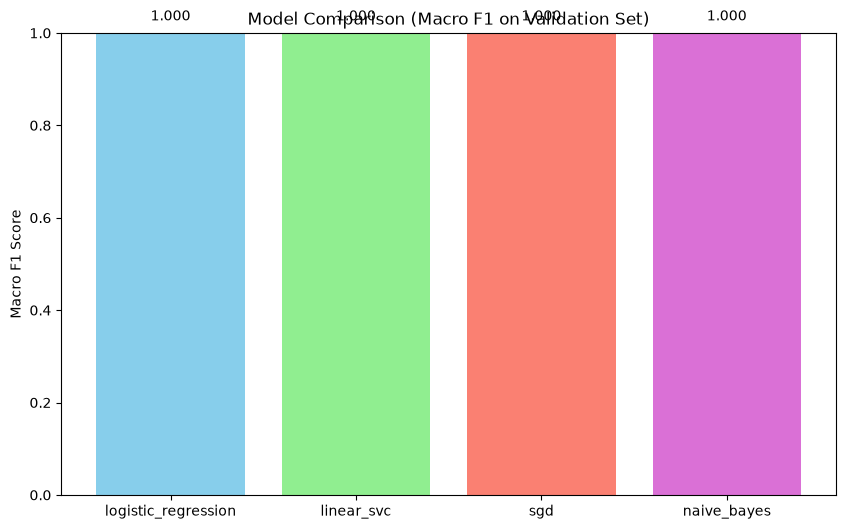

In [5]:
plt.figure(figsize=(10, 6))
bars = plt.bar(f1_scores.keys(), f1_scores.values(), color=['skyblue', 'lightgreen', 'salmon', 'orchid'])
plt.title("Model Comparison (Macro F1 on Validation Set)")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1)

# Add scores on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom')

plt.show()